In [1]:
# Source: https://www.youtube.com/watch?v=A2NUo93MyH0&t=5s
from datetime import datetime
from zoneinfo import ZoneInfo

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
def fix_yf_df(yf_df: pd.DataFrame) -> pd.DataFrame:
    # Transform to long format: Date and Ticker as columns, single-level headers
    df = yf_df.stack(future_stack=True, level=0).rename_axis(["Date", "symbols"])
    # Remove the 'Price' name from the columns index
    df.columns.name = None

    if isinstance(df, pd.Series):
        raise TypeError(f"df is of type {type(df)} instead of pd.DataFrame")

    df.sort_values(["symbols", "Date"], inplace=True)
    df.reset_index(inplace=True)
    zi = ZoneInfo("US/Eastern")
    df["Date"] = df["Date"].apply(
        lambda x: datetime.fromisoformat(str(x)).astimezone(zi)
    )

    if "Adj Close" in df.columns:
        del df["Adj Close"]

    df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume",
    }, inplace=True)

    return df.set_index("Date")

In [3]:
# Get the stock data
df = yf.download(
    "GDX", group_by="Ticker", start="2013-01-01",
    end="2023-02-28", auto_adjust=True
)

data = fix_yf_df(df)

[*********************100%***********************]  1 of 1 completed


In [4]:
data.head()

,symbols,open,high,low,close,volume
Date,,,,,,
2013-01-02 00:00:00-05:00,GDX,42.099694,42.367106,41.814454,41.983814,13210600
2013-01-03 00:00:00-05:00,GDX,41.662921,41.948161,40.174321,40.236717,22829200
2013-01-04 00:00:00-05:00,GDX,39.924734,40.406078,39.666235,40.406078,16822300
2013-01-07 00:00:00-05:00,GDX,39.978215,40.156491,39.612751,39.648407,15483900
2013-01-08 00:00:00-05:00,GDX,39.684062,39.844510,39.211634,39.799942,11815600


In [5]:
data["returns"] = np.log(data["close"] / data["close"].shift(1))

In [6]:
# Defining a trend path
SMA = 25

In [7]:
data["SMA"] = data["close"].rolling(SMA).mean()

In [8]:
# Setting a threshold for signal to open long or short
threshold = 2

In [9]:
data["distance"] = data["close"] - data["SMA"]

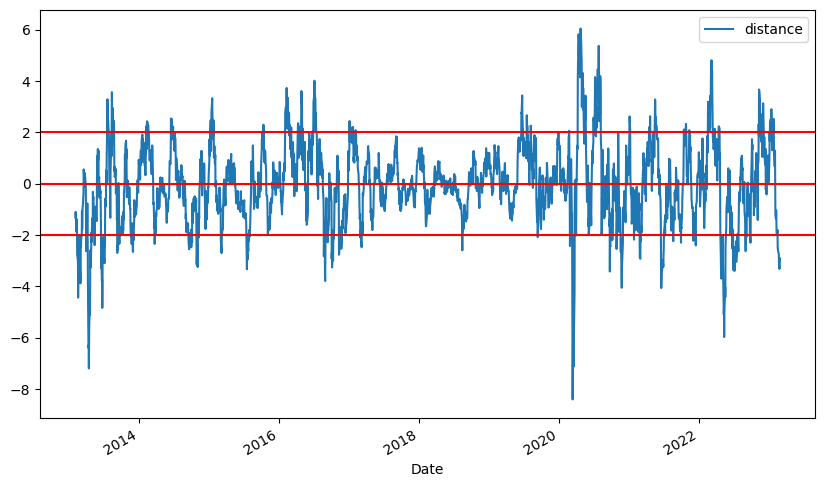

In [10]:
data["distance"].dropna().plot(figsize=(10, 6), legend=True)
plt.axhline(threshold, color='r')
plt.axhline(-threshold, color='r')
plt.axhline(0, color='r')

In [11]:
# When trend line is greater than upper threshold --> short
data["position"] = np.where(data["distance"] > threshold, -1, np.nan)

In [12]:
# When trend is less than lower threshold --> long
data["position"] = np.where(data["distance"] < -threshold, 1, data["position"])

In [13]:
# When trend cross back into threshold area --> close position (go neutral)
data["position"] = np.where(
    data["distance"] * data["distance"].shift(1) < 0, 0, data["position"]
)

In [14]:
# Fill NA's with 0
data["position"] = data["position"].ffill().fillna(0)

<Axes: xlabel='Date'>

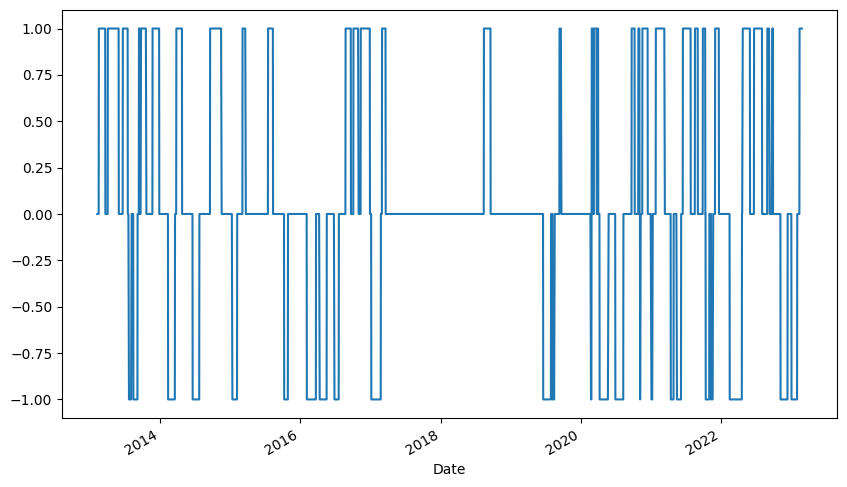

In [15]:
# Plot
data["position"].iloc[SMA:].plot(ylim=[-1.1, 1.1], figsize=(10, 6))

In [16]:
data["strategy"] = data["position"].shift(1) * data["returns"]

<Axes: xlabel='Date'>

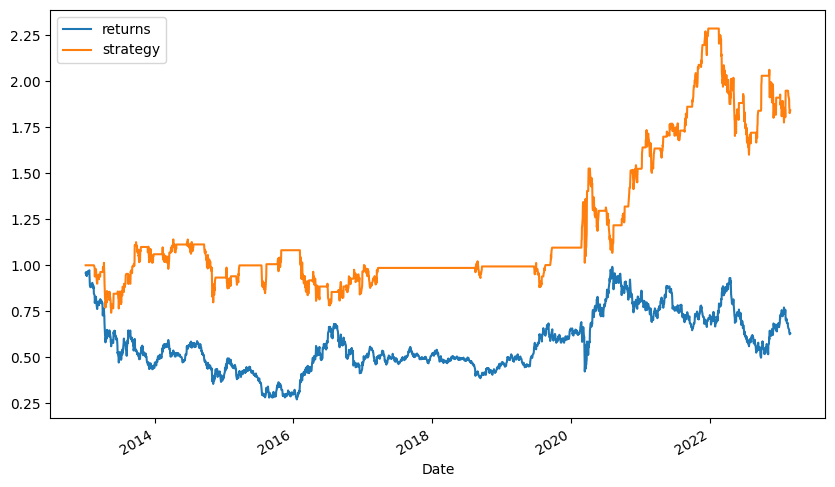

In [17]:
data[["returns", "strategy"]].dropna().cumsum().apply(np.exp).plot(figsize=(10, 6))